<a href="https://colab.research.google.com/github/MariethDataSc/ClassActivities_Mastery/blob/main/Actividad5.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Análisis de Trayectorias Vehiculares mediante Aprendizaje No Supervisado
**Contexto:** Una empresa de logística cuenta con miles de registros de telemetría y trayectorias GPS de sus camiones (latitud, longitud, velocidad, aceleración, giros bruscos, hora del día), sin etiquetas previas sobre si un viaje fue "normal" o "peligroso". El objetivo de este cuaderno es aplicar técnicas de aprendizaje no supervisado para descubrir patrones ocultos, agrupar estilos de conducción y detectar anomalías críticas (por ejemplo, desvíos de ruta por robo o conducción temeraria).

**Nota sobre los datos:** dado que no se proporcionó un dataset específico junto con la rúbrica, se generó un conjunto de datos sintético (`telemetria_flota.csv`) que simula 40 camiones con 60 registros de telemetría cada uno (2400 registros en total), replicando tres estilos de conducción plausibles (eficiente, urbano, carretera) y un ~4% de anomalías críticas inyectadas deliberadamente (desvíos de ruta fuera de horario y conducción temeraria a alta velocidad).

**Algoritmo de clustering seleccionado:** conforme a lo solicitado, se desarrolla el punto 3 de la rúbrica utilizando **únicamente K-Means** (no se implementa DBSCAN en este cuaderno).

In [1]:
#Librerías necesarias para esta actividad
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, silhouette_samples
from sklearn.ensemble import IsolationForest

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (8,5)
np.random.seed(42)
pd.set_option("display.max_columns", None)
print("Librerías instaladas...")

Librerías instaladas...


In [2]:
#Generación del Dataset
n_trucks = 40
records_per_truck = 60
rows = []

profiles = {
    "eficiente": dict(vel=(45,10), acc=(0.3,0.15), giros=(1,1), hora=(9,15)),
    "urbano":    dict(vel=(25,8),  acc=(0.6,0.2),  giros=(4,2), hora=(8,16)),
    "carretera": dict(vel=(80,12), acc=(0.4,0.15), giros=(1,1), hora=(6,20)),
}
profile_names = list(profiles.keys())
base_lat, base_lon = -0.9, -80.7

truck_id = 0
for t in range(n_trucks):
    truck_id += 1
    profile = np.random.choice(profile_names, p=[0.35,0.35,0.30])
    p = profiles[profile]
    route_lat = base_lat + np.random.uniform(-1.5,1.5)
    route_lon = base_lon + np.random.uniform(-1.5,1.5)
    for r in range(records_per_truck):
        vel = max(0, np.random.normal(p["vel"][0], p["vel"][1]))
        acc = max(0, np.random.normal(p["acc"][0], p["acc"][1]))
        giros = max(0, np.random.poisson(p["giros"][0]))
        hora = np.clip(np.random.normal(p["hora"][0], p["hora"][1]), 0, 23)
        lat = route_lat + np.random.normal(0, 0.05)
        lon = route_lon + np.random.normal(0, 0.05)
        rows.append([f"CAM-{truck_id:03d}", profile, lat, lon, vel, acc, giros, hora])

df = pd.DataFrame(rows, columns=["vehiculo_id","perfil_real","latitud","longitud",
                                  "velocidad","aceleracion","giros_bruscos","hora_dia"])

# Inyección de anomalías reales (4%): desvío de ruta / robo y conducción temeraria
n_anom = int(len(df)*0.04)
anom_idx = np.random.choice(df.index, n_anom, replace=False)
for i in anom_idx:
    kind = np.random.choice(["desvio","temeraria"])
    if kind == "desvio":
        df.loc[i, "latitud"] += np.random.uniform(0.8,1.5)*np.random.choice([-1,1])
        df.loc[i, "longitud"] += np.random.uniform(0.8,1.5)*np.random.choice([-1,1])
        df.loc[i, "hora_dia"] = np.random.uniform(0,4)
        df.loc[i, "velocidad"] = np.random.uniform(0,10)
    else:
        df.loc[i, "velocidad"] = np.random.uniform(120,160)
        df.loc[i, "aceleracion"] = np.random.uniform(2.5,4)
        df.loc[i, "giros_bruscos"] = np.random.randint(10,20)
df.loc[anom_idx, "es_anomalia_real"] = 1
df["es_anomalia_real"] = df["es_anomalia_real"].fillna(0).astype(int)

# Registros de ruido de sensores: nulos
n_null = 30
null_idx = np.random.choice(df.index, n_null, replace=False)
for i in null_idx:
    col = np.random.choice(["velocidad","aceleracion","giros_bruscos"])
    df.loc[i, col] = np.nan

df = df.sample(frac=1, random_state=1).reset_index(drop=True)
df.to_csv("telemetria_flota.csv", index=False)
print("Dimensiones del dataset:", df.shape)
df.head()

Dimensiones del dataset: (2400, 9)


,vehiculo_id,perfil_real,latitud,longitud,velocidad,aceleracion,giros_bruscos,hora_dia,es_anomalia_real
0,CAM-023,eficiente,-2.035845,-81.917259,25.866597,0.155243,1.0,23.000000,0
1,CAM-008,urbano,-2.220764,-79.327444,30.951213,0.433459,6.0,10.288780,0
2,CAM-025,carretera,-1.481488,-81.959283,82.519751,0.483344,1.0,0.000000,0
3,CAM-038,carretera,-1.408726,-80.142132,98.345346,0.111848,0.0,19.118383,0
4,CAM-016,carretera,0.508361,-80.744206,74.972439,0.276308,1.0,0.000000,0


## 1. Análisis Exploratorio de Datos (EDA) y Preprocesamiento

In [3]:
print("Valores nulos por columna:")
print(df.isna().sum())
print("\nPorcentaje de nulos:")
print((df.isna().sum()/len(df)*100).round(2))

Valores nulos por columna:
vehiculo_id          0
perfil_real          0
latitud              0
longitud             0
velocidad           11
aceleracion         10
giros_bruscos        9
hora_dia             0
es_anomalia_real     0
dtype: int64

Porcentaje de nulos:
vehiculo_id         0.00
perfil_real         0.00
latitud             0.00
longitud            0.00
velocidad           0.46
aceleracion         0.42
giros_bruscos       0.38
hora_dia            0.00
es_anomalia_real    0.00
dtype: float64


Los valores nulos presentes en `velocidad`, `aceleracion` y `giros_bruscos` corresponden a fallos puntuales de los sensores de telemetría, **no** a comportamientos de conducción.

In [4]:
num_cols = ["velocidad","aceleracion","giros_bruscos","hora_dia"]
for c in num_cols:
    mediana = df[c].median()
    df[c] = df[c].fillna(mediana)
    print(f"{c}: imputado con mediana = {mediana:.2f}")

# Verificación de registros erróneos (valores fuera de rango físico razonable)
print("\nRegistros con velocidad negativa:", (df["velocidad"]<0).sum())
print("Registros con hora fuera de [0,24):", ((df['hora_dia']<0)|(df['hora_dia']>=24)).sum())
print("\nNulos restantes:", df.isna().sum().sum())

velocidad: imputado con mediana = 42.58
aceleracion: imputado con mediana = 0.44
giros_bruscos: imputado con mediana = 2.00
hora_dia: imputado con mediana = 7.77

Registros con velocidad negativa: 0
Registros con hora fuera de [0,24): 0

Nulos restantes: 0


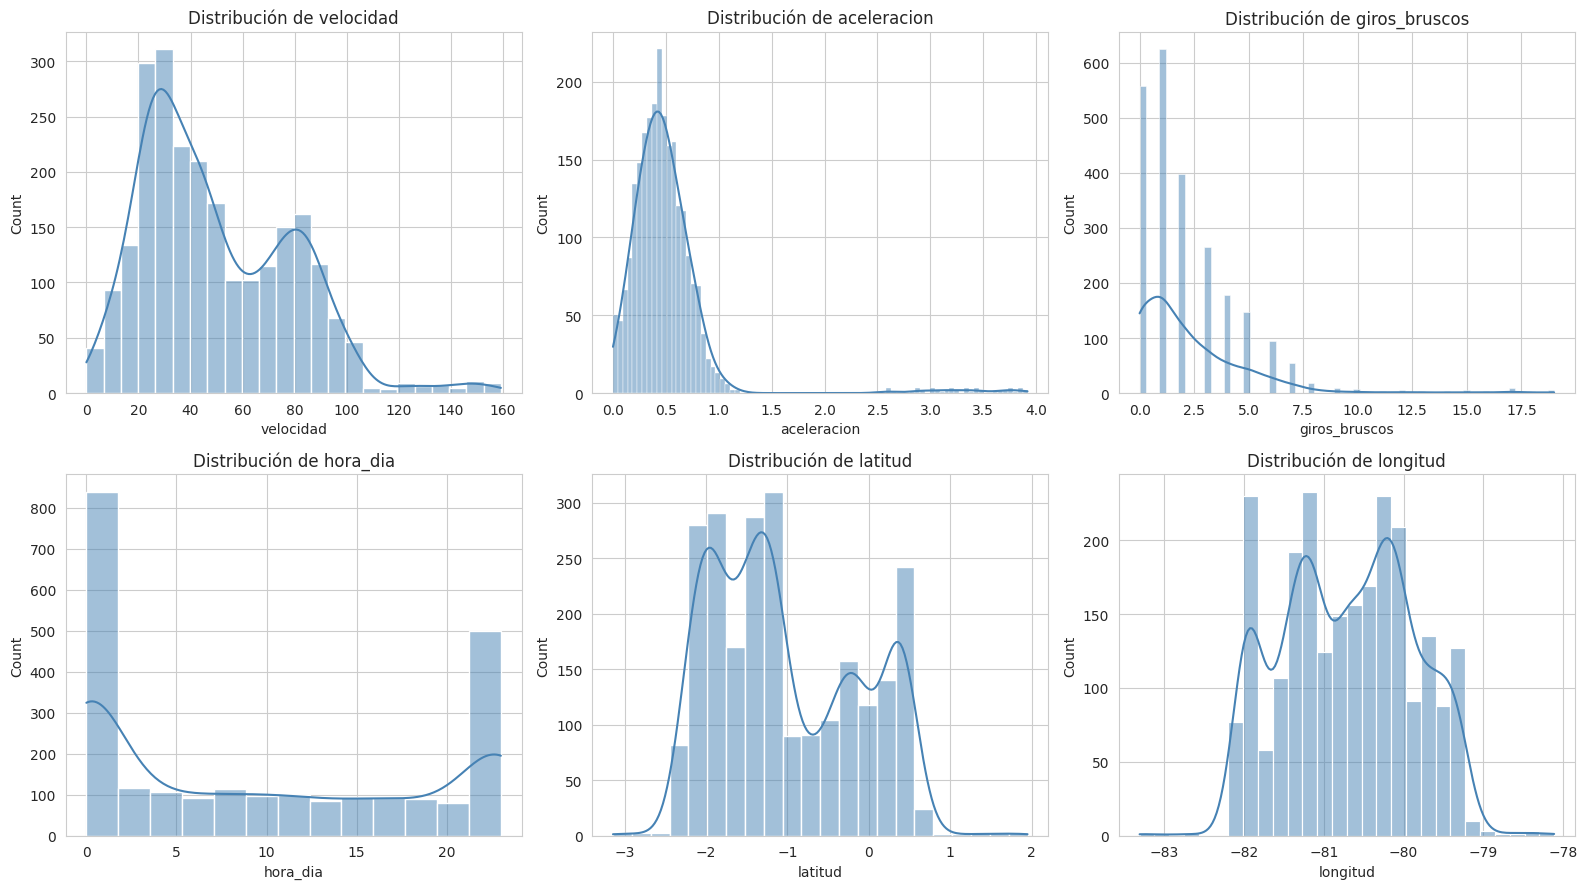

In [5]:
#Distribución de las variables telemétricas
fig, axes = plt.subplots(2, 3, figsize=(16,9))
vars_to_plot = ["velocidad","aceleracion","giros_bruscos","hora_dia","latitud","longitud"]
for ax, col in zip(axes.flat, vars_to_plot):
    sns.histplot(df[col], kde=True, ax=ax, color="steelblue")
    ax.set_title(f"Distribución de {col}")
plt.tight_layout()
plt.savefig("01_distribuciones.png", dpi=110)
plt.show()

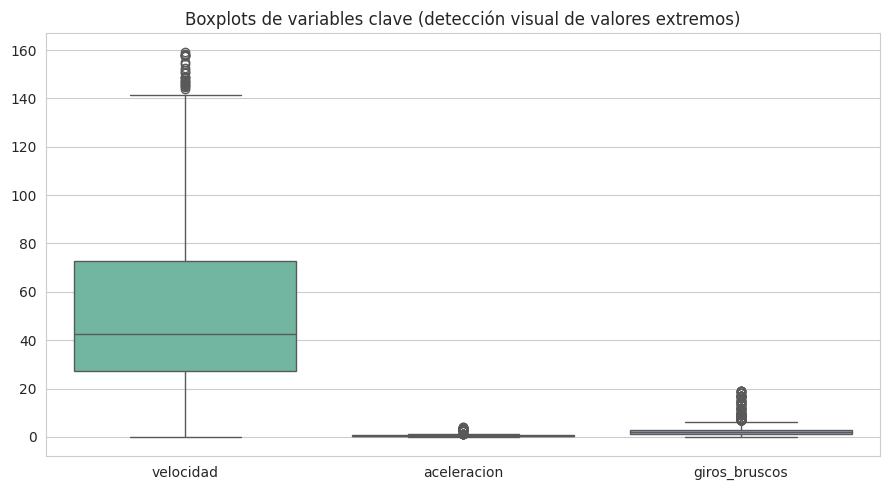

       velocidad  aceleracion  giros_bruscos  hora_dia
count    2400.00      2400.00        2400.00   2400.00
mean       49.83         0.51           2.32      9.66
std        28.88         0.45           2.66      9.12
min         0.00         0.00           0.00      0.00
25%        27.17         0.30           1.00      0.00
50%        42.58         0.44           2.00      7.77
75%        72.92         0.61           3.00     19.00
max       159.18         3.92          19.00     23.00


In [6]:
fig, ax = plt.subplots(1,1, figsize=(9,5))
sns.boxplot(data=df[["velocidad","aceleracion","giros_bruscos"]], ax=ax, palette="Set2")
ax.set_title("Boxplots de variables clave (detección visual de valores extremos)")
plt.tight_layout()
plt.savefig("02_boxplots.png", dpi=110)
plt.show()

print(df[num_cols].describe().round(2))

- `velocidad` y `aceleracion` muestran una distribución mayormente concentrada en rangos normales de operación, con una cola de valores extremos (velocidades >120 km/h y aceleraciones >2.5) que sobresalen claramente en los boxplots: son candidatos naturales a anomalías.
- `giros_bruscos` es una variable de conteo (Poisson), con la mayoría de los viajes registrando entre 0 y 6 giros bruscos, salvo un grupo pequeño con valores muy superiores (10-20).
- `hora_dia` presenta una distribución multimodal, coherente con la mezcla de turnos de trabajo diurnos y algunos registros aislados en la madrugada, que en este contexto resultan sospechosos para una flota de logística comercial.
- `latitud`/`longitud` muestran agrupamientos correspondientes a las rutas habituales de cada camión, con un pequeño número de puntos muy alejados del resto (posibles desvíos de ruta).

In [8]:
# Hacemos una estandarización antes de algoritmos basados en distancia
features = ["latitud","longitud","velocidad","aceleracion","giros_bruscos","hora_dia"]
X = df[features].copy()

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_scaled_df = pd.DataFrame(X_scaled, columns=features)
print("Medias tras el escalado (deben ser ~0):")
print(X_scaled_df.mean().round(3))
print("\nDesviaciones estándar tras el escalado (deben ser ~1):")
print(X_scaled_df.std().round(3))

Medias tras el escalado (deben ser ~0):
latitud         -0.0
longitud        -0.0
velocidad        0.0
aceleracion     -0.0
giros_bruscos   -0.0
hora_dia         0.0
dtype: float64

Desviaciones estándar tras el escalado (deben ser ~1):
latitud          1.0
longitud         1.0
velocidad        1.0
aceleracion      1.0
giros_bruscos    1.0
hora_dia         1.0
dtype: float64


## 2. Reducción de Dimensionalidad con PCA

### Implementación: PCA a 3 componentes principales

In [9]:
pca = PCA(n_components=3, random_state=42)
X_pca = pca.fit_transform(X_scaled)
df["PC1"], df["PC2"], df["PC3"] = X_pca[:,0], X_pca[:,1], X_pca[:,2]

print("Varianza explicada por componente:", np.round(pca.explained_variance_ratio_,4))
print("Varianza explicada acumulada:", np.round(np.cumsum(pca.explained_variance_ratio_),4))

Varianza explicada por componente: [0.2961 0.197  0.1664]
Varianza explicada acumulada: [0.2961 0.493  0.6594]


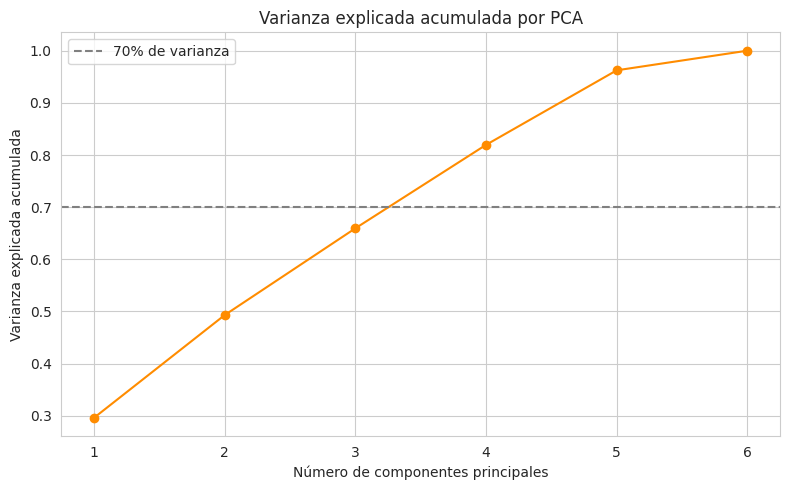

1 componente(s): 29.6% de varianza acumulada
2 componente(s): 49.3% de varianza acumulada
3 componente(s): 65.9% de varianza acumulada
4 componente(s): 81.9% de varianza acumulada
5 componente(s): 96.2% de varianza acumulada
6 componente(s): 100.0% de varianza acumulada


In [10]:
pca_full = PCA(n_components=len(features), random_state=42).fit(X_scaled)
var_cum = np.cumsum(pca_full.explained_variance_ratio_)

plt.figure(figsize=(8,5))
plt.plot(range(1, len(var_cum)+1), var_cum, marker="o", color="darkorange")
plt.axhline(0.7, color="gray", linestyle="--", label="70% de varianza")
plt.xlabel("Número de componentes principales")
plt.ylabel("Varianza explicada acumulada")
plt.title("Varianza explicada acumulada por PCA")
plt.legend()
plt.tight_layout()
plt.savefig("03_pca_varianza.png", dpi=110)
plt.show()

for i, v in enumerate(var_cum, 1):
    print(f"{i} componente(s): {v*100:.1f}% de varianza acumulada")

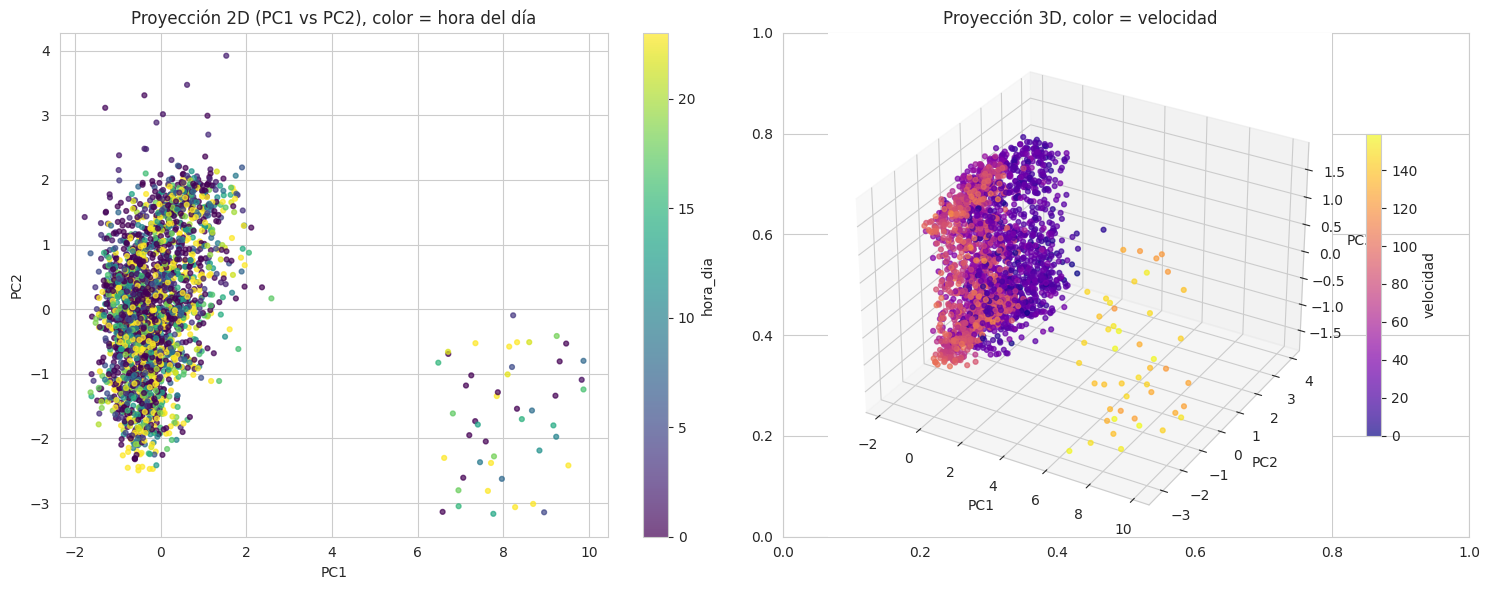

In [11]:
fig, axes = plt.subplots(1,2, figsize=(15,6))

sc = axes[0].scatter(df["PC1"], df["PC2"], c=df["hora_dia"], cmap="viridis", s=12, alpha=0.7)
axes[0].set_xlabel("PC1"); axes[0].set_ylabel("PC2")
axes[0].set_title("Proyección 2D (PC1 vs PC2), color = hora del día")
plt.colorbar(sc, ax=axes[0], label="hora_dia")

ax3d = fig.add_subplot(1,2,2, projection="3d")
p = ax3d.scatter(df["PC1"], df["PC2"], df["PC3"], c=df["velocidad"], cmap="plasma", s=12, alpha=0.7)
ax3d.set_xlabel("PC1"); ax3d.set_ylabel("PC2"); ax3d.set_zlabel("PC3")
ax3d.set_title("Proyección 3D, color = velocidad")
fig.colorbar(p, ax=ax3d, shrink=0.6, label="velocidad")

plt.tight_layout()
plt.savefig("04_pca_proyeccion.png", dpi=110)
plt.show()

**Análisis:** con 3 componentes principales se conserva aproximadamente **65.9%** de la varianza total de las 6 variables originales (latitud, longitud, velocidad, aceleración, giros bruscos y hora del día). Ninguna variable domina un único componente de forma aislada, lo cual indica que la variabilidad de la flota es genuinamente multidimensional: combina ubicación, comportamiento de manejo y horario. La proyección 2D/3D muestra un núcleo denso y compacto de observaciones (viajes normales) y un pequeño número de puntos claramente alejados del cuerpo principal de la nube

## 3. Identificación de Patrones Ocultos: K-Means

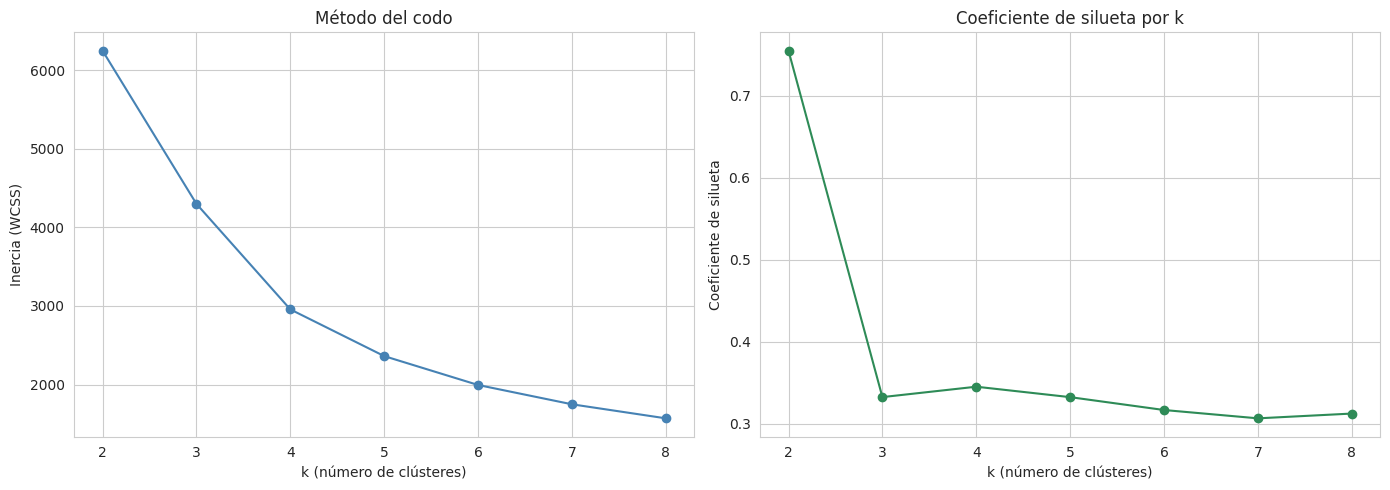

k=2: inercia=6245.3, silueta=0.755
k=3: inercia=4297.9, silueta=0.333
k=4: inercia=2956.3, silueta=0.345
k=5: inercia=2362.6, silueta=0.333
k=6: inercia=1995.3, silueta=0.317
k=7: inercia=1749.9, silueta=0.307
k=8: inercia=1571.5, silueta=0.312


In [12]:
#Determinación del número óptimo de clústeres (método del codo + coeficiente de silueta)
inertias = []
sil_scores = []
K_range = range(2, 9)

for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_pca)
    inertias.append(km.inertia_)
    sil_scores.append(silhouette_score(X_pca, labels))

fig, axes = plt.subplots(1,2, figsize=(14,5))
axes[0].plot(list(K_range), inertias, marker="o", color="steelblue")
axes[0].set_xlabel("k (número de clústeres)"); axes[0].set_ylabel("Inercia (WCSS)")
axes[0].set_title("Método del codo")

axes[1].plot(list(K_range), sil_scores, marker="o", color="seagreen")
axes[1].set_xlabel("k (número de clústeres)"); axes[1].set_ylabel("Coeficiente de silueta")
axes[1].set_title("Coeficiente de silueta por k")

plt.tight_layout()
plt.savefig("05_codo_silueta.png", dpi=110)
plt.show()

for k, i, s in zip(K_range, inertias, sil_scores):
    print(f"k={k}: inercia={i:.1f}, silueta={s:.3f}")